In [10]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from idlpy import *
import cartopy.crs as ccrs
import cartopy.feature as cf
import matplotlib as mpl
from pylab import *

IDL 8.7.2 (linux x86_64 m64).
(c) 2019, Harris Geospatial Solutions, Inc.

A new version is available: IDL 9.0
https://www.nv5geospatialsoftware.com/Product-Downloads/
 
Licensed for use by: NIWA - National Institute of Water and Atmospheric Research Ltd - Ashley
License: 229483-BUF
Expiration date: 31-Mar-2024


In [14]:
'''
Create vegetation land masks
'''
ERA5 = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/FWI_6month_fire_season_ERA5_resolution.nc')
d4pdf = xr.open_dataarray('/nesi/nobackup/niwa00015/queenle/d4PDF/6m_fire_season/naturalized/naturalized_FWI_HPB_ensMean.nc')
cam5 = xr.open_dataarray('/nesi/nobackup/niwa00015/queenle/CAM5/6m_fire_season/naturalized/naturalized_FWI_All_ensMean.nc')

vege_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/monthly/vegetation/1951-2021.nc')
vege_ds['longitude'] = [lon + 360 for lon in vege_ds.longitude.data]
era5_combined = (vege_ds.lai_hv + vege_ds.lai_lv).max('time')
era5_vege_mask = era5_combined.where(era5_combined>3.5)

vege_ds_coarsened = vege_ds.coarsen(latitude=3,longitude=3,boundary='pad').mean()

cam5_vege = vege_ds_coarsened.interp(longitude=cam5.longitude, latitude=cam5.latitude, method="linear")
cam5_combined = (cam5_vege.lai_hv + cam5_vege.lai_lv).max('time')
cam5_vege_mask = cam5_combined.where(cam5_combined>3.5)

d4pdf_vege = vege_ds_coarsened.interp(longitude=d4pdf.longitude, latitude=d4pdf.latitude, method="linear")
d4pdf_combined = (d4pdf_vege.lai_hv + d4pdf_vege.lai_lv).max('time')
d4pdf_vege_mask = d4pdf_combined.where(d4pdf_combined>3.5)

box = [(32,55),(232,256)]

def get_linregress_slope(arr):
    if (np.isnan(arr)).any():
        result = np.nan
    else:
        result = np.polyfit([i for i in range(len(arr))],arr,deg=1)[0]
        
    return(result)

In [4]:
def percentage_of_max(val):
    return((val/mx)*100)

Text(-0.18, 0.255, 'CAM5 \n(1959-2014)')

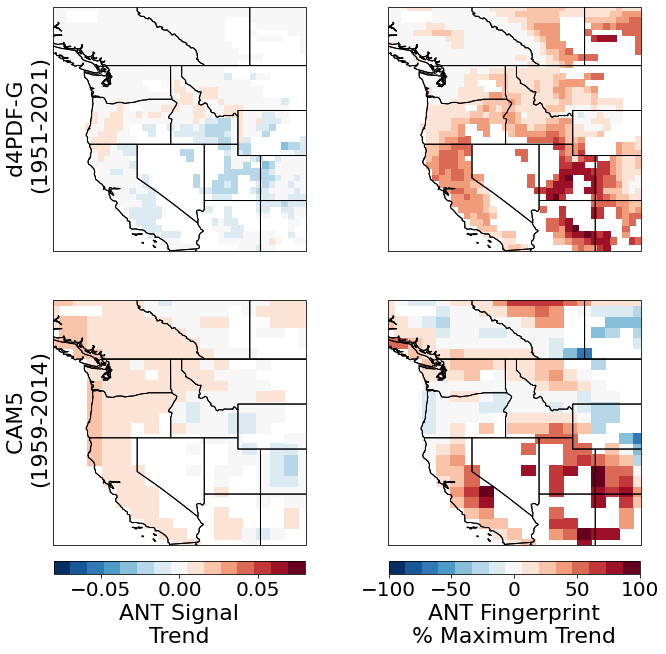

In [30]:
fig,axs = plt.subplots(2,2,figsize=(11,12),subplot_kw=dict(projection=ccrs.PlateCarree()))#,layout='constrained')
cmap = cm.get_cmap('RdBu_r', 15)

font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 22,
        }

for i,model in enumerate(['d4pdf','cam5']):
    
    era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/'+model+'_resolution/FWI_6month_fire_season_'+model+'_resolution.nc')

    if model == 'cam5':
        scen_dict = {'ALL':'All','NAT':'Nat'}
        start,end = ('1959','2014')
        vege_mask = cam5_vege_mask
        Ant_da = xr.open_dataset('/nesi/nobackup/niwa00015/queenle/CAM5/6m_fire_season/naturalized/naturalized_FWI_Ant_ensMean.nc')

    if model == 'd4pdf':
        scen_dict = {'ALL':'HPB','NAT':'HPB_NAT'}
        start,end = ('1951','2021')
        vege_mask = d4pdf_vege_mask
        Ant_da = xr.open_dataset('/nesi/nobackup/niwa00015/queenle/d4PDF/6m_fire_season/naturalized/naturalized_FWI_Ant_ensMean.nc')

    Ant_da = Ant_da.rename({'FWI':'Ant'})
    Ant_da = Ant_da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
    Ant_da = Ant_da.where(vege_mask>0)
    Ant_da = Ant_da.where(~era5_da.isnull())
    
    fingerprint_da = xr.open_dataarray('/home/queenle/fire_attribution/result_files/'+model+'_naturalized_TA_RH_fingerprint_'+start+'_'+end+'.nc')
    
    ant_im = xr.apply_ufunc(get_linregress_slope, Ant_da['Ant'], input_core_dims=[["time"]], vectorize = True).plot(ax=axs[i][0],transform=ccrs.PlateCarree(),vmin=-0.08,vmax=0.08,cmap=cmap,add_colorbar=False)
    
    fingerprint_trend = xr.apply_ufunc(get_linregress_slope, fingerprint_da, input_core_dims=[["time"]], vectorize = True)

    mx = fingerprint_trend.max().data.tolist()

    finger_im = xr.apply_ufunc(percentage_of_max, fingerprint_trend).plot(ax=axs[i][1],transform=ccrs.PlateCarree(),vmin=-100,vmax=100,cmap=cmap,add_colorbar=False)

    for j in range(2):
        axs[i][j].coastlines()  # cartopy function
        axs[i][j].add_feature(cf.BORDERS)
        axs[i][j].add_feature(cf.STATES)
        axs[i][j].set_extent([232.5,255, 32.5,54.18])
    
cb = fig.colorbar(ant_im, ax=axs[0:2, 0], shrink=0.9, orientation='horizontal',pad=0.025)
cb.set_label(label='ANT Signal\nTrend',fontdict=font)
cb.ax.tick_params(labelsize=20)

cb = fig.colorbar(finger_im, ax=axs[0:2, 1], shrink=0.9, orientation='horizontal',pad=0.025)
cb.set_label(label='ANT Fingerprint\n% Maximum Trend',fontdict=font)
cb.ax.tick_params(labelsize=20)
cb.ax.xaxis.offsetText.set(size=16)


axs[0][0].text(-0.18,0.255,'d4PDF-G \n(1951-2021)',fontdict=font,transform=axs[0][0].transAxes, rotation='vertical',ma='center')
axs[1][0].text(-0.18,0.255,'CAM5 \n(1959-2014)',fontdict=font,transform=axs[1][0].transAxes, rotation='vertical',ma='center')

#plt.savefig('../figures/Figure4.png',dpi=300)

Text(-0.18, 0.255, 'CAM5 \n(1959-2014)')

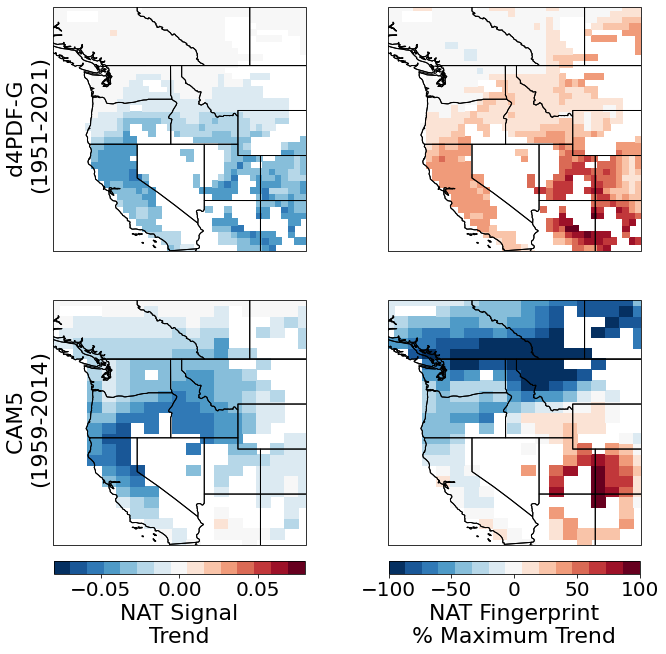

In [41]:
fig,axs = plt.subplots(2,2,figsize=(11,12),subplot_kw=dict(projection=ccrs.PlateCarree()))#,layout='constrained')
cmap = cm.get_cmap('RdBu_r', 15)

font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 22,
        }

for i,model in enumerate(['d4pdf','cam5']):
    
    era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/'+model+'_resolution/FWI_6month_fire_season_'+model+'_resolution.nc')

    if model == 'cam5':
        scen_dict = {'ALL':'All','NAT':'Nat'}
        start,end = ('1959','2014')
        vege_mask = cam5_vege_mask
        nat_da = xr.open_dataset('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_Nat_ensMean.nc')

    if model == 'd4pdf':
        scen_dict = {'ALL':'HPB','NAT':'HPB_NAT'}
        start,end = ('1951','2021')
        vege_mask = d4pdf_vege_mask
        nat_da = xr.open_dataset('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_HPB_NAT_ensMean.nc')


    nat_da = nat_da.rename({'FWI':'Nat'})
    nat_da = nat_da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
    nat_da = nat_da.where(vege_mask>0)
    nat_da = nat_da.where(~era5_da.isnull())
    
    fingerprint_da = xr.open_dataarray('/home/queenle/fire_attribution/result_files/'+model+'_naturalized_TA_RH_NAT_fingerprint_'+start+'_'+end+'.nc')
    
    nat_im = xr.apply_ufunc(get_linregress_slope, nat_da['Nat'], input_core_dims=[["time"]], vectorize = True).plot(ax=axs[i][0],transform=ccrs.PlateCarree(),vmin=-0.08,vmax=0.08,cmap=cmap,add_colorbar=False)
    
    fingerprint_trend = xr.apply_ufunc(get_linregress_slope, fingerprint_da, input_core_dims=[["time"]], vectorize = True)

    mx = fingerprint_trend.max().data.tolist()

    finger_im = xr.apply_ufunc(percentage_of_max, fingerprint_trend).plot(ax=axs[i][1],transform=ccrs.PlateCarree(),vmin=-100,vmax=100,cmap=cmap,add_colorbar=False)

    for j in range(2):
        axs[i][j].coastlines()  # cartopy function
        axs[i][j].add_feature(cf.BORDERS)
        axs[i][j].add_feature(cf.STATES)
        axs[i][j].set_extent([232.5,255, 32.5,54.18])
    
cb = fig.colorbar(nat_im, ax=axs[0:2, 0], shrink=0.9, orientation='horizontal',pad=0.025)
cb.set_label(label='NAT Signal\nTrend',fontdict=font)
cb.ax.tick_params(labelsize=20)

cb = fig.colorbar(finger_im, ax=axs[0:2, 1], shrink=0.9, orientation='horizontal',pad=0.025)
cb.set_label(label='NAT Fingerprint\n% Maximum Trend',fontdict=font)
cb.ax.tick_params(labelsize=20)
cb.ax.xaxis.offsetText.set(size=16)


axs[0][0].text(-0.18,0.255,'d4PDF-G \n(1951-2021)',fontdict=font,transform=axs[0][0].transAxes, rotation='vertical',ma='center')
axs[1][0].text(-0.18,0.255,'CAM5 \n(1959-2014)',fontdict=font,transform=axs[1][0].transAxes, rotation='vertical',ma='center')

#plt.savefig('../figures/Figure4.png',dpi=300)

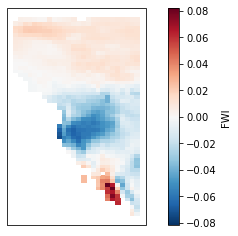

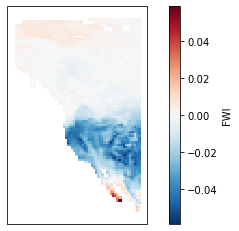

In [32]:
for model in ['cam5','d4pdf']:
    fig,axs = plt.subplots(figsize=(8,4),subplot_kw=dict(projection=ccrs.PlateCarree()))
    if model == 'cam5':
        nat_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_Nat_ensMean.nc')
    elif model == 'd4pdf':
        nat_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_HPB_NAT_ensMean.nc')

    nat_im = xr.apply_ufunc(get_linregress_slope, nat_mean, input_core_dims=[["time"]], vectorize = True).plot(ax=axs,transform=ccrs.PlateCarree())#,vmin=-0.08,vmax=0.08,cmap=cmap,add_colorbar=False)

    plt.show()
    plt.close()


In [35]:
'''
create dataset with d4pdf All, Nat, Ant signals and Nat and Ant fingerprints from finger_trans
'''

def save_fingerprint(model,Ant_da,finger_trans,start_year, end_year):

    da = Ant_da.sel(time=slice(start_year,end_year))
    
    pixel = da.stack(pixel=("latitude", "longitude"))
    no_nan = pixel.dropna("pixel", how="all")
    shape = no_nan.Ant.data.shape

    # add fingerprints
    all_finger_trans = np.array([val[0] for val in finger_trans])
    nat_finger_trans = -1*np.array([val[1] for val in finger_trans])
    ant_finger_trans = all_finger_trans - nat_finger_trans

    nat_finger_from_trans = (1/(nat_finger_trans+1)-1)
    ant_finger_from_trans = (1/(ant_finger_trans+1)-1)

    add_fingers = no_nan.assign(nat_finger_from_trans=(['time','lev','pixel'],nat_finger_from_trans.reshape(shape)),
                                ant_finger_from_trans=(['time','lev','pixel'],ant_finger_from_trans.reshape(shape)),
                                )

    unstack = add_fingers.unstack("pixel")
    
    #nstack['ant_finger_from_trans'].to_netcdf('/home/queenle/fire_attribution/result_files/'+model+'_naturalized_TA_RH_fingerprint_'+start_year+'_'+end_year+'.nc')
    unstack['nat_finger_from_trans'].to_netcdf('/home/queenle/fire_attribution/result_files/'+model+'_naturalized_TA_RH_NAT_fingerprint_'+start_year+'_'+end_year+'.nc')


    

In [36]:
font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 16,
        }


for i,model in enumerate(['cam5','d4pdf']):
    
    era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/'+model+'_resolution/FWI_6month_fire_season_'+model+'_resolution.nc')

    if model == 'cam5':
        scen_dict = {'ALL':'All','NAT':'Nat'}
        start,end = ('1959','2014')
        vege_mask = cam5_vege_mask
        Ant_da = xr.open_dataset('/nesi/nobackup/niwa00015/queenle/CAM5/6m_fire_season/naturalized/naturalized_FWI_Ant_ensMean.nc')

    if model == 'd4pdf':
        scen_dict = {'ALL':'HPB','NAT':'HPB_NAT'}
        start,end = ('1951','2021')
        vege_mask = d4pdf_vege_mask
        Ant_da = xr.open_dataset('/nesi/nobackup/niwa00015/queenle/d4PDF/6m_fire_season/naturalized/naturalized_FWI_Ant_ensMean.nc')

    Ant_da = Ant_da.rename({'FWI':'Ant'})
    Ant_da = Ant_da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
    Ant_da = Ant_da.where(vege_mask>0)
    Ant_da = Ant_da.where(~era5_da.isnull())
    
    IDL.retall

    print('getting ALL mean and noise')
    all_ens_mean,noise_all = get_mean_and_noise(model, scen_dict['ALL'], box, vege_mask, start, end)
    print('getting NAT mean and noise')
    nat_ens_mean,noise_nat = get_mean_and_noise(model, scen_dict['NAT'], box, vege_mask, start, end)

    print('getting obs')
    data_obs = get_obs_data(model, box, vege_mask, start, end)
    print('got obs')
    data_scen = np.array([all_ens_mean,nat_ens_mean])

    if model == 'cam5':
        data_noise_1 = np.concatenate((noise_all[:22],noise_nat[:24]))
        data_noise_2 = np.concatenate((noise_all[22:],noise_nat[24:]))

    else:
        data_noise_1 = np.concatenate((noise_all[:50],noise_nat[:50]))
        data_noise_2 = np.concatenate((noise_all[50:],noise_nat[50:]))
        
    print('got arrays')

    if model == 'cam5':
        trunc = 30
    if model == 'd4pdf':
        trunc = 60
        
    IDL.data_obs = data_obs
    IDL.data_scen = data_scen
    IDL.data_noise_1 = data_noise_1
    IDL.data_noise_2 = data_noise_2
    IDL.trunc = trunc
    IDL.finger_trans = 1

    #print('running gendetec')
    IDL.run("gendetec, data_obs, data_scen, data_noise_1, beta_est, \
            data_noise_2=data_noise_2,transform=['1*0','1*0+1*1'], trunc=trunc, finger_trans=finger_trans")

    finger_trans = IDL.finger_trans

    save_fingerprint(model,Ant_da,finger_trans,start, end)

getting ALL mean and noise
getting NAT mean and noise
getting obs
got obs
got arrays
getting ALL mean and noise
getting NAT mean and noise
getting obs
got obs
got arrays


In [24]:

def get_obs_data(model, box, vege_mask, start_year, end_year):
    
    if model == 'cam5':
        model_da = xr.open_dataarray('/nesi/nobackup/niwa00015/queenle/CAM5/6m_fire_season/naturalized/naturalized_FWI_All_ensMean.nc')
        era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/cam5_resolution/FWI_6month_fire_season_cam5_resolution.nc')
    else:
        model_da = xr.open_dataarray('/nesi/nobackup/niwa00015/queenle/d4PDF/6m_fire_season/naturalized/naturalized_FWI_HPB_ensMean.nc')
        era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/d4pdf_resolution/FWI_6month_fire_season_d4pdf_resolution.nc')

    if box != 'full':
        era5_da = era5_da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))

    era5_da = era5_da.where(vege_mask>0)
        
    era5_da = era5_da.sel(time=slice(start_year,end_year))
    era5_da = era5_da.where(~model_da.isnull())
    
    era5_da = era5_da.stack(pixel=("latitude", "longitude"))
    era5_da = era5_da.dropna("pixel", how="all")        
    
    array = era5_da.values.flatten()
        
    return(array)


In [26]:
def get_noise(model,era5_da,scen,ens_mean,box,vege_mask,start_year,end_year):
    
    if model == 'cam5':
        runs = {'All':[i for i in range(1,11)] + [i for i in range(36,44)] + [i for i in range(61,71)] + [i for i in range(86,101)],
                'Nat':[i for i in range(1,11)] + [i for i in range(36,51)] + [i for i in range(61,71)] + [i for i in range(86,96)] + [i for i in range(97,101)]}
    else:
        runs = {'HPB':range(1,101),
                'HPB_NAT':range(1,101)}
    noise = []
    for ens_mem in runs[scen]:
        if ens_mem == 100:
            number = '100'
        else:
            number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)

        if model == 'cam5':
            if scen == 'All':
                mem_da = xr.open_dataarray('/nesi/nobackup/niwa00015/queenle/CAM5/6m_fire_season/naturalized/naturalized_FWI_All_run'+number+'.nc')
            elif scen == 'Nat':
                mem_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_'+scen+'_run'+number+'.nc')
        
        elif model == 'd4pdf':
            if scen == 'HPB':
                mem_da = xr.open_dataarray('/nesi/nobackup/niwa00015/queenle/d4PDF/6m_fire_season/naturalized/naturalized_FWI_HPB_m'+number+'.nc')
            elif scen == 'HPB_NAT':
                mem_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_'+scen+'_m'+number+'.nc')

        if box != 'full':
            mem_da = mem_da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))

        mem_da = mem_da.where(vege_mask>0)

        mem_da = mem_da.sel(time=slice(start_year,end_year))
        mem_da = mem_da.where(~era5_da.isnull())

        diff = mem_da - ens_mean

        diff = diff.stack(pixel=("latitude", "longitude"))# Create a MultiIndex
        diff = diff.dropna("pixel", how="all")# Drop the pixels that only have NA values.
                
        diff_array = diff.values.flatten()
        noise.append(diff_array)
        
    return(noise)



In [25]:
def get_mean_and_noise(model, scen, box, vege_mask, start_year, end_year):
    
    if model == 'cam5':
        era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/cam5_resolution/FWI_6month_fire_season_cam5_resolution.nc')
        if scen == 'All':
            ens_mean = xr.open_dataarray('/nesi/nobackup/niwa00015/queenle/CAM5/6m_fire_season/naturalized/naturalized_FWI_All_ensMean.nc')
        elif scen == 'Nat':
            ens_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_'+scen+'_ensMean.nc')
    else:
        era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/d4pdf_resolution/FWI_6month_fire_season_d4pdf_resolution.nc')
        if scen == 'HPB':
            ens_mean = xr.open_dataarray('/nesi/nobackup/niwa00015/queenle/d4PDF/6m_fire_season/naturalized/naturalized_FWI_HPB_ensMean.nc')
        elif scen == 'HPB_NAT':
            ens_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_'+scen+'_ensMean.nc')
    
    if box != 'full':
        ens_mean = ens_mean.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))

    ens_mean = ens_mean.where(vege_mask>0)
        
    ens_mean = ens_mean.sel(time=slice(start_year,end_year))
    ens_mean = ens_mean.where(~era5_da.isnull())
    
    noise = get_noise(model,era5_da,scen,ens_mean,box,vege_mask,start_year,end_year)

    ens_mean = ens_mean.stack(pixel=("latitude", "longitude"))# Create a MultiIndex
    ens_mean = ens_mean.dropna("pixel", how="all")# Drop the pixels that only have NA values.
    ens_mean_array = ens_mean.values.flatten()
    
    return((ens_mean_array, np.array(noise)))
